## **Rolling Kyle's Lambda**

### **Methodology: Rolling Kyle's Lambda via Cont et al. OFI**

**1. The Theoretical Framework**
Kyle's Lambda ($\lambda$) is a foundational microstructure metric used to quantify market depth and the permanent price impact of trading activity. The standard regression is modeled as:

$$\Delta P_t = \alpha + \lambda \cdot S_t + \epsilon_t$$

Where $\Delta P_t$ is the mid-price change and $S_t$ is the signed trade volume.

**2. The Order Flow Imbalance (OFI) Proxy**
Because the available dataset consists of Level 1 limit order book snapshots rather than an executed trade tape, signed trade volume cannot be directly measured. Order Flow Imbalance (OFI) serves as a robust proxy. To account for market maker algorithmic cancellations and limit order repositioning, the calculation utilizes the rigorous Cont, Kukanov, and Puhle (2014) state-conditional formula:

$$e_t = I(P^b_t \ge P^b_{t-1}) V^b_t - I(P^b_t \le P^b_{t-1}) V^b_{t-1} - I(P^a_t \le P^a_{t-1}) V^a_t + I(P^a_t \ge P^a_{t-1}) V^a_{t-1}$$

Where $P^b$ and $V^b$ represent the bid price and size, $P^a$ and $V^a$ represent the ask price and size, and $I(\cdot)$ is an indicator function. 
**3. Rolling Ordinary Least Squares (OLS) Regression**
Liquidity is not stationary; it expands and contracts violently in response to macroeconomic shocks. To capture this dynamic behavior, the static OLS regression is transformed into a Rolling OLS model. By applying a 24-hour (1,440-minute) lookback window, the algorithm computes a continuous time series of $\lambda$. This prevents localized liquidity droughts from being smoothed over by monthly averages.

---

### **Results and Conclusions: The USDC Depeg Liquidity Shock**

The generated multi-plot dashboard captures the microstructure contagion caused by the Silicon Valley Bank (SVB) collapse and the subsequent USDC depeg perfectly. 

**1. The Stablecoin Panic (Micro-Scale Spikes)**
* **Pairs:** `KRAKEN_USDC_USD`, `KRAKEN_USDT_USD`
* **Conclusion:** In absolute terms, the market impact for these fiat-pegged assets remains infinitesimally small (operating on a $10^{-9}$ and $10^{-10}$ scale). However, the visual structure reveals a massive relative liquidity shock exactly between the Depeg (March 11) and Repeg (March 13) events. As uncertainty peaked regarding USDC's reserves, market makers drastically widened spreads and pulled resting limit orders to avoid adverse selection, resulting in the sharp $\lambda$ peaks.

**2. The Core Liquidity Contraction**
* **Pairs:** `COINBASE_BTC_USD`, `KRAKEN_BTC_USDC`
* **Conclusion:** Both of these pairs experienced severe liquidity droughts (high $\lambda$ spikes) perfectly synchronized with the depeg. Because USDC is heavily integrated into the broader crypto ecosystem, the failure of a major quote currency's peg temporarily hollowed out the order books for primary Bitcoin pairs.

**3. The USDT "Safe Haven" Rotation**
* **Pair:** `COINBASE_BTC_USDT`
* **Conclusion:** This chart provides a fascinating counter-narrative. While most pairs saw $\lambda$ spike (indicating a liquidity drop) during the depeg, `COINBASE_BTC_USDT` saw its $\lambda$ crash toward zero precisely during the March 11–13 window. This illustrates capital rotation. As traders fled failing USDC pairs, they sought safety in USDT (Tether). This sudden influx of trading activity temporarily thickened the USDT order books, absorbing market impact. 
**4. Prolonged Microstructure Friction**
* **General Observation:** Across almost all non-stablecoin pairs, the highest $\lambda$ values actually occur in the final week of March, well after the USDC repeg. This indicates that the SVB collapse triggered a prolonged period of caution among algorithmic market makers, keeping order books relatively thin as broader banking contagion fears persisted.

Starting rolling data processing...
Processing COINBASE_BTC_USD (Loaded 21 daily files)...
Processing COINBASE_BTC_USDT (Loaded 20 daily files)...

--- Missing Files Log ---
Missing: ORDERBOOK FIXED/2023-03-21/COINBASE_BTC_USDT_ob_2023-03-21.csv


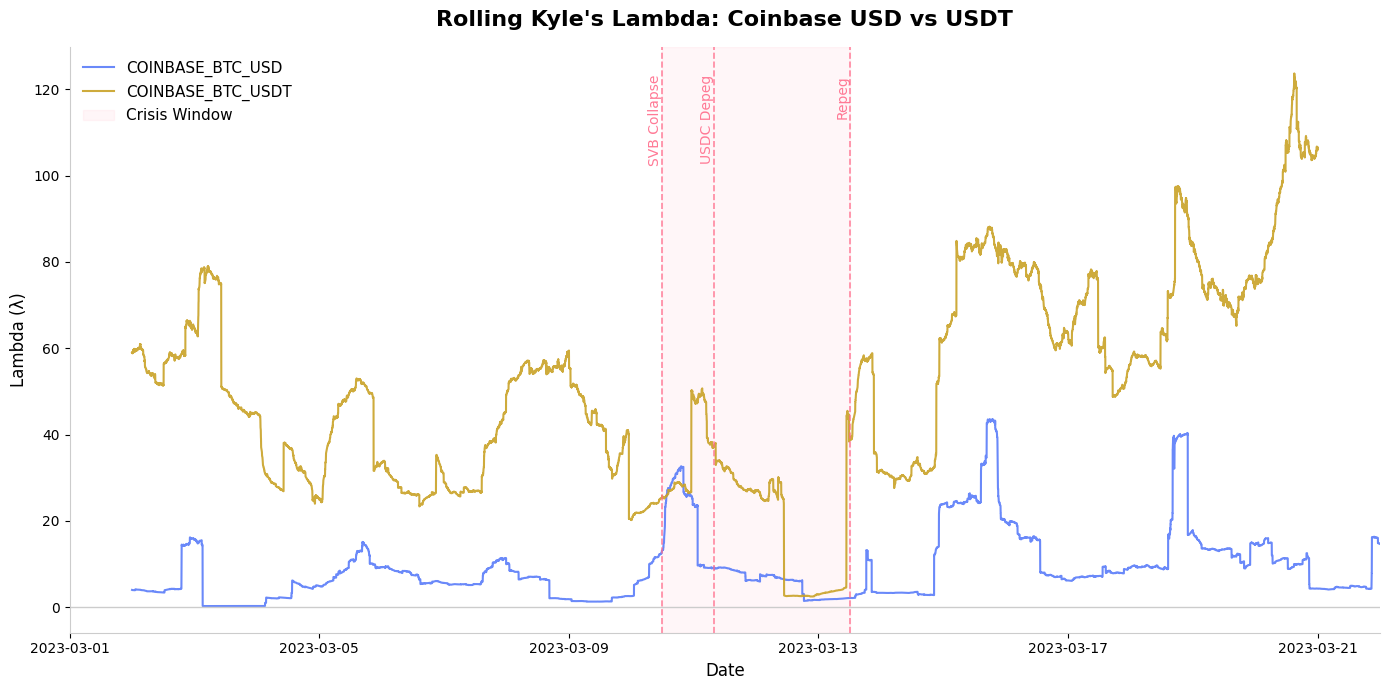


Processing complete! Graph saved as 'coinbase_lambda_comparison.png'


In [2]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import matplotlib.pyplot as plt
from pathlib import Path

# Corrected relative path based on your VS Code workspace
root_dir = Path("ORDERBOOK FIXED")

# Target Universe - Restricted to just the two Coinbase pairs
pairs = [
    "COINBASE_BTC_USD",
    "COINBASE_BTC_USDT"
]

rolling_results = {}
missing_files_log = []

print("Starting rolling data processing...")

for pair in pairs:
    pair_dfs = []
    
    # Iterate from March 1 to March 21
    for i in range(1, 22):
        date_str = f"2023-03-{str(i).zfill(2)}"
        date_folder = root_dir / date_str
        file_name = f"{pair}_ob_{date_str}.csv"
        file_path = date_folder / file_name
        
        if file_path.exists():
            df = pd.read_csv(file_path)
            df.columns = df.columns.str.strip()
            df['time_exchange'] = pd.to_datetime(df['time_exchange'])
            pair_dfs.append(df)
        else:
            missing_files_log.append(str(file_path))
                
    if not pair_dfs:
        print(f"  [!] No data found for {pair}.")
        continue
        
    print(f"Processing {pair} (Loaded {len(pair_dfs)} daily files)...")
    
    # Concatenate and sort
    master_df = pd.concat(pair_dfs, ignore_index=True)
    master_df.sort_values(by="time_exchange", inplace=True)
    
    # 1. Cont et al. OFI Calculation
    master_df['delta_p'] = master_df['mid_price'].diff()
    
    prev_bid_p = master_df['bid_price_1'].shift(1)
    prev_bid_v = master_df['bid_size_1'].shift(1)
    prev_ask_p = master_df['ask_price_1'].shift(1)
    prev_ask_v = master_df['ask_size_1'].shift(1)
    
    curr_bid_p = master_df['bid_price_1']
    curr_bid_v = master_df['bid_size_1']
    curr_ask_p = master_df['ask_price_1']
    curr_ask_v = master_df['ask_size_1']
    
    cond_bid = [curr_bid_p > prev_bid_p, curr_bid_p == prev_bid_p, curr_bid_p < prev_bid_p]
    choice_bid = [curr_bid_v, curr_bid_v - prev_bid_v, -prev_bid_v]
    master_df['bid_imb'] = np.select(cond_bid, choice_bid, default=0)
    
    cond_ask = [curr_ask_p < prev_ask_p, curr_ask_p == prev_ask_p, curr_ask_p > prev_ask_p]
    choice_ask = [curr_ask_v, curr_ask_v - prev_ask_v, -prev_ask_v]
    master_df['ask_imb'] = np.select(cond_ask, choice_ask, default=0)
    
    master_df['OFI'] = master_df['bid_imb'] - master_df['ask_imb']
    master_df.dropna(subset=['delta_p', 'OFI'], inplace=True)
    
    # 2. Set index for rolling operation
    master_df.set_index('time_exchange', inplace=True)
    
    # 3. Resample the data to 1-minute intervals
    df_1m = master_df[['delta_p', 'OFI']].resample('1min').sum()
    df_1m.dropna(inplace=True)
    
    # 4. ROLLING OLS Regression (24-hour window = 1440 minutes)
    X = df_1m['OFI']
    X = sm.add_constant(X)
    y = df_1m['delta_p']
    
    window_size = 1440 
    
    if len(df_1m) > window_size:
        roll_reg = RollingOLS(endog=y, exog=X, window=window_size).fit(params_only=True)
        # Extract the rolling lambda coefficient
        rolling_results[pair] = roll_reg.params['OFI']
    else:
        print(f"  [!] Not enough data to compute 24h rolling window for {pair}.")

# Print missing files log
if missing_files_log:
    print("\n--- Missing Files Log ---")
    for missing in missing_files_log:
        print(f"Missing: {missing}")

# --- Plotting the Single Overlay Graph ---
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')

# Colors mapped directly to the two specific pairs
pair_colors = {
    "COINBASE_BTC_USD": '#5a7cf9',  # Blueish
    "COINBASE_BTC_USDT": '#c9a227'  # Goldish
}

# Determine timezone status to match limits safely
is_tz_aware = len(rolling_results) > 0 and list(rolling_results.values())[0].index.tz is not None
min_date = pd.to_datetime('2023-03-01').tz_localize('UTC') if is_tz_aware else pd.to_datetime('2023-03-01')
max_date = pd.to_datetime('2023-03-22').tz_localize('UTC') if is_tz_aware else pd.to_datetime('2023-03-22')

# Define Events
events = {
    'SVB Collapse': '2023-03-10 12:00:00',
    'USDC Depeg': '2023-03-11 08:00:00',
    'Repeg': '2023-03-13 12:00:00'
}
crisis_start = pd.to_datetime('2023-03-10 12:00:00')
crisis_end = pd.to_datetime('2023-03-13 12:00:00')

# Plot lines
for pair in rolling_results:
    ax.plot(rolling_results[pair].index, rolling_results[pair].values, 
            label=pair, color=pair_colors[pair], linewidth=1.5, alpha=0.9)

# Plot crisis shading
ax.axvspan(crisis_start, crisis_end, color='#ff6b8a', alpha=0.06, label='Crisis Window')

# Plot event markers
for event, dt_str in events.items():
    dt = pd.to_datetime(dt_str)
    ax.axvline(x=dt, color='#ff6b8a', linestyle='--', alpha=0.8, linewidth=1.2)
    ax.text(dt, ax.get_ylim()[1]*0.95, event, color='#ff6b8a', rotation=90, 
            verticalalignment='top', horizontalalignment='right', alpha=0.9, fontsize=10)

# Formatting
ax.axhline(0, color='#cccccc', linewidth=1, linestyle='-')
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.set_xlim([min_date, max_date])

ax.set_title("Rolling Kyle's Lambda: Coinbase USD vs USDT", fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel("Lambda (λ)", fontsize=12)
ax.set_xlabel("Date", fontsize=12)
ax.legend(loc='upper left', frameon=False, fontsize=11)

plt.tight_layout()
plt.savefig('coinbase_lambda_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\nProcessing complete! Graph saved as 'coinbase_lambda_comparison.png'")

To quantify the price impact of the market depth, a regression model was run based on the foundational framework established by Kyle (1985). Kyle's standard regression is modeled as:

$$\Delta P_t = \alpha + \lambda \cdot S_t + \epsilon_t$$

Where $\Delta P_t$ is the mid-price change and $S_t$ is the signed trade volume. However, as the dataset contained limit order book snapshots rather than executed trades, $S_t$ were proxied using the robust Order Flow Imbalance (OFI) metric as proposed by Cont, Kukanov, and Puhle (2014) via the state conditional formula:

$$e_t = I(P^b_t \ge P^b_{t-1}) V^b_t - I(P^b_t \le P^b_{t-1}) V^b_{t-1} - I(P^a_t \le P^a_{t-1}) V^a_t + I(P^a_t \ge P^a_{t-1}) V^a_{t-1}$$

Where $P^b$ and $V^b$ represent the bid price and size, $P^a$ and $V^a$ represent the ask price and size, and $I(\cdot)$ is an indicator function. This synthesis allows us to get a rather granular estimate for price impact of trading activity in modern electronic markets. Knowing that liquidity is not constant but rather chnages drastically with shocks, the static OLS regression is replaced with a Rolling OLS model. In this model, we calculates a time series of $\lambda$ based on 24-hour (1,440-minute) lookback windows, preventing smoothing over monthly averages. Higher $\lambda$ values represent the occurence of liquidity droughts. <br>

As evident, the market impact, $\lambda$, for fiat pegged assets on Kraken, `KRAKEN_USDC_USD` and `KRAKEN_USDT_USD`, had been negligible prior to the depegging event. However, there was a large relative liquidity shock during the depegging event as market makers pulled resting limit orders to avoid adverse selection. Although the order book went back to normal for `KRAKEN_USDC_USD` after the repegging, liquidity for `KRAKEN_USDT_USD` remained scarce relatively to prior periods for longer. `COINBASE_BTC_USD`, which can also be looked at as `COINBASE_BTC_USDC` as the exchange unifies `USDC` and `USD` on a 1:1 basis, faced extreme liquidity shocks, while `COINBASE_BTC_USDT` acted as a "relative" safe haven with its $\lambda$ dropping from its previous high values to those of the `USD` pair. This shows that the depegging event thickened the USDT orderbooks. Finally, it is observed that the $\lambda$ values for all stablecoin pairs remain high after the repegging, which means that the SVB contagion triggered a prolonged fear in the market and kept order books thin. 

<br>Citations:
- Cont, R., Kukanov, A., & Puhle, S. (2014). The Price Impact of Order Book Events. Journal of Financial Econometrics, 12(1), 47–88. https://doi.org/10.1093/jjfinec/nbt003
- Kyle, A. S. (1985). Continuous Auctions and Insider Trading. Econometrica, 53(6), 1315–1335. https://doi.org/10.2307/1913210
